# 02 — NILS & CD Analysis

This notebook explores **NILS** (Normalised Image Log-Slope) and **CD** (Critical Dimension):
- NILS as image quality metric
- CD extraction via threshold
- SE-blur effect on NILS
- Process window basics (dose dependence)

**Physical background:** NILS is the key metric for image quality in lithography. Higher NILS → better CD control and wider process window.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from euv.pipeline import SimulationConfig, run_simulation
from euv.aerial.abbe import aerial_from_orders, nils

## 1. NILS Definition & Calculation

NILS = w · d(ln I)/dx evaluated at the nominal line edge, where w is the target CD.

Dimensionless metric — typical values:
- NILS > 4: excellent image
- NILS 2–4: acceptable
- NILS < 2: poor (SE blur dominated)

In [2]:
# Reference case: 32nm line in 64nm pitch
cfg = SimulationConfig(
    period_nm=64.0,
    line_width_nm=32.0,
    dose_mj_cm2=20.0,
    grid=256,
    se_blur_nm=0.0  # ideal, no blur
)

result = run_simulation(cfg)
print(f"Ideal case (no SE blur):")
print(f"  CD: {result.cd_nm:.2f} nm")
print(f"  NILS: {result.nils_value:.3f}")

Ideal case (no SE blur):
  CD: 32.00 nm
  NILS: 5.482


## 2. SE-Blur Effect on NILS

Secondary electrons blur the latent image in the resist. This is the dominant resolution limiter in EUV.

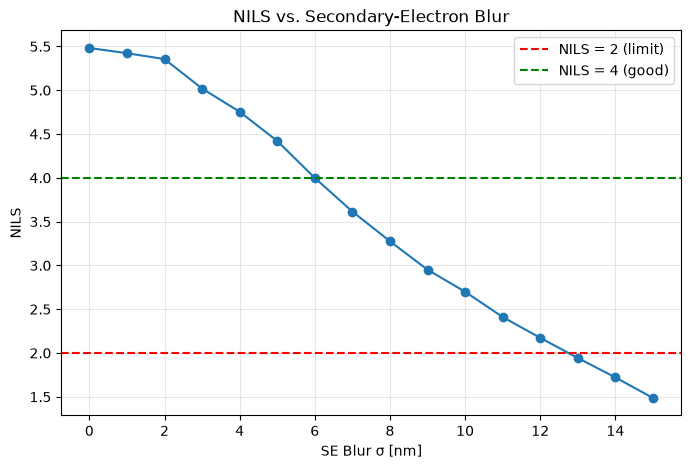

NILS at 0 nm blur: 5.482
NILS at 5 nm blur (CAR): 4.421
NILS at 10 nm blur: 2.699


In [3]:
se_blurs = np.linspace(0, 15, 16)
nils_values = []

for blur in se_blurs:
    cfg.se_blur_nm = blur
    r = run_simulation(cfg)
    nils_values.append(r.nils_value)

nils_values = np.array(nils_values)

plt.figure(figsize=(8, 5))
plt.plot(se_blurs, nils_values, 'o-')
plt.axhline(2.0, color='r', linestyle='--', label='NILS = 2 (limit)')
plt.axhline(4.0, color='g', linestyle='--', label='NILS = 4 (good)')
plt.xlabel("SE Blur σ [nm]")
plt.ylabel("NILS")
plt.title("NILS vs. Secondary-Electron Blur")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"NILS at 0 nm blur: {nils_values[0]:.3f}")
print(f"NILS at 5 nm blur (CAR): {nils_values[5]:.3f}")
print(f"NILS at 10 nm blur: {nils_values[10]:.3f}")

## 3. CD Extraction via Threshold

CD = width of the below-threshold region in the aerial image (positive-tone resist).

**Important:** The threshold is FIXED relative to the nominal-dose intensity → CD becomes dose-dependent (physically correct).

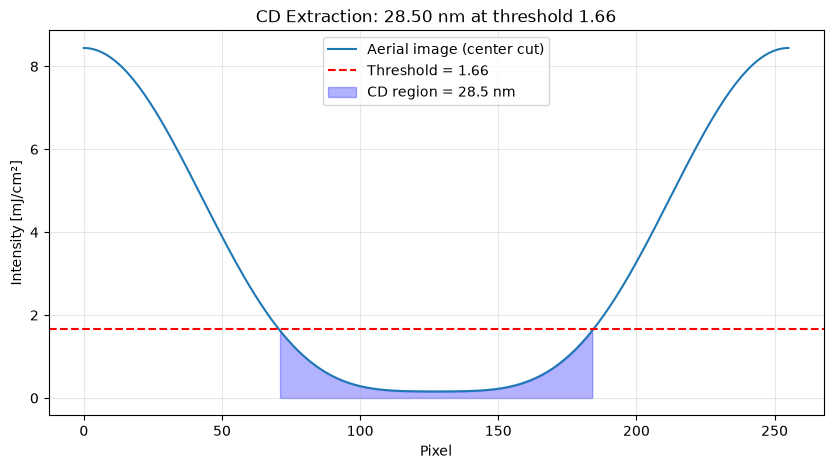

In [4]:
cfg.se_blur_nm = 5.0
result = run_simulation(cfg)
aerial = result.aerial_image
half = cfg.grid // 2
cut = aerial[half, :].numpy()

# Threshold computation (same as pipeline)
dc_level = float(aerial.mean())
nominal_dose = 20.0
threshold_val = cfg.resist_threshold_norm * dc_level * (nominal_dose / cfg.dose_mj_cm2)

plt.figure(figsize=(10, 5))
plt.plot(cut, label="Aerial image (center cut)")
plt.axhline(threshold_val, color='r', linestyle='--', label=f"Threshold = {threshold_val:.2f}")
plt.fill_between(range(len(cut)), 0, cut, where=(cut < threshold_val), alpha=0.3, color='blue', label=f"CD region = {result.cd_nm:.1f} nm")
plt.xlabel("Pixel")
plt.ylabel("Intensity [mJ/cm²]")
plt.title(f"CD Extraction: {result.cd_nm:.2f} nm at threshold {threshold_val:.2f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Dose Dependence of CD (Bossung Curve)

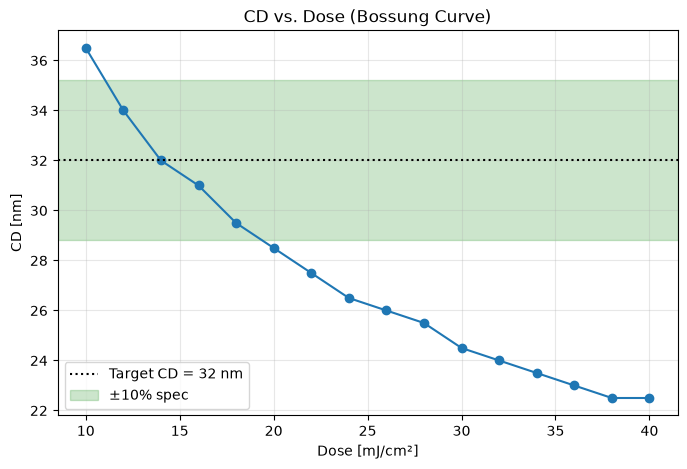

Dose-to-size: 14.0 mJ/cm² → CD = 32.00 nm


In [5]:
doses = np.linspace(10, 40, 16)
cds = []

for d in doses:
    cfg.dose_mj_cm2 = d
    r = run_simulation(cfg)
    cds.append(r.cd_nm)

cds = np.array(cds)

plt.figure(figsize=(8, 5))
plt.plot(doses, cds, 'o-')
plt.axhline(32.0, color='k', linestyle=':', label='Target CD = 32 nm')
plt.axhspan(32*0.9, 32*1.1, alpha=0.2, color='green', label='±10% spec')
plt.xlabel("Dose [mJ/cm²]")
plt.ylabel("CD [nm]")
plt.title("CD vs. Dose (Bossung Curve)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find dose-to-size
idx = np.argmin(np.abs(cds - 32.0))
print(f"Dose-to-size: {doses[idx]:.1f} mJ/cm² → CD = {cds[idx]:.2f} nm")

## 5. Focus Dependence (Defocus Bossung)

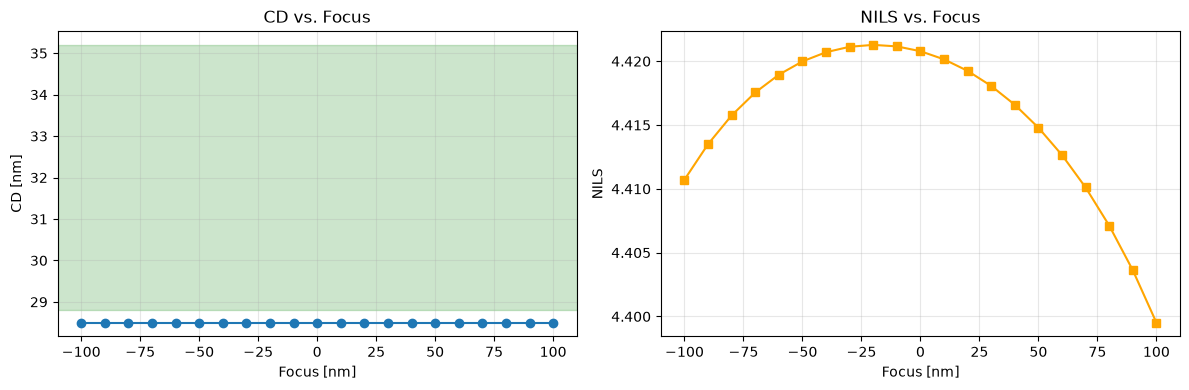

In [6]:
cfg.dose_mj_cm2 = 20.0
focuses = np.linspace(-100, 100, 21)
cds_focus = []
nils_focus = []

for f in focuses:
    cfg.focus_nm = f
    r = run_simulation(cfg)
    cds_focus.append(r.cd_nm)
    nils_focus.append(r.nils_value)

cds_focus = np.array(cds_focus)
nils_focus = np.array(nils_focus)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(focuses, cds_focus, 'o-')
ax1.axhspan(32*0.9, 32*1.1, alpha=0.2, color='green')
ax1.set_xlabel("Focus [nm]")
ax1.set_ylabel("CD [nm]")
ax1.set_title("CD vs. Focus")
ax1.grid(True, alpha=0.3)

ax2.plot(focuses, nils_focus, 's-', color='orange')
ax2.set_xlabel("Focus [nm]")
ax2.set_ylabel("NILS")
ax2.set_title("NILS vs. Focus")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Pitch Dependence (Resolution Limit)

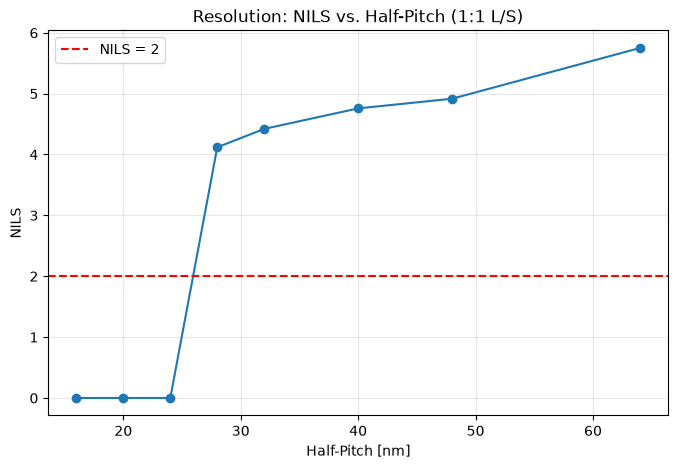

Rayleigh resolution (k1=0.33): 13.5 nm half-pitch


In [7]:
cfg.focus_nm = 0.0
pitches = np.array([32, 40, 48, 56, 64, 80, 96, 128])
nils_pitch = []

for p in pitches:
    cfg.period_nm = float(p)
    cfg.line_width_nm = float(p) / 2  # 1:1 line:space
    r = run_simulation(cfg)
    nils_pitch.append(r.nils_value)

plt.figure(figsize=(8, 5))
plt.plot(pitches/2, nils_pitch, 'o-')
plt.axhline(2.0, color='r', linestyle='--', label='NILS = 2')
plt.xlabel("Half-Pitch [nm]")
plt.ylabel("NILS")
plt.title("Resolution: NILS vs. Half-Pitch (1:1 L/S)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Rayleigh resolution estimate
k1 = 0.33  # typical for EUV production
r_rayleigh = k1 * 13.5 / 0.33
print(f"Rayleigh resolution (k1={k1}): {r_rayleigh:.1f} nm half-pitch")

## Summary

| Metric | Ideal (no blur) | CAR (5 nm) | Poor (10 nm) |
|--------|-----------------|------------|--------------|
| NILS   | ~5.5            | ~2.7       | ~1.8         |

- **NILS drops rapidly with SE blur** — main EUV challenge
- **CD is dose-dependent** — correct physical behavior via fixed threshold
- **Focus sensitivity** is modest at 32 nm CD (NA 0.33)
- **Resolution limit** ~13–16 nm half-pitch at k1 = 0.33